# Phase 3 — Explainability (SHAP)

This notebook follows the project plan: **global** SHAP (beeswarm / summary) and **local** SHAP (waterfall) for the XGBoost score.

**Models** — `model/model_calibrated.pkl` supplies **isotonic-calibrated** probabilities (same artefact as `src.train`). `model/model_uncalibrated.pkl` is the underlying preprocess + `XGBClassifier` for `TreeExplainer`. Run **`uv run python -m src.train`** from the repo root if either file is missing.


In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore", category=UserWarning)


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").is_file() and (p / "src" / "metrics.py").is_file():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml + src/).")


ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT))

RANDOM_STATE = 42
TEST_SIZE = 0.2
DB_PATH = ROOT / "data" / "home_credit.db"

/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import duckdb
from sklearn.model_selection import train_test_split
from src.features import build_feature_matrix

conn = duckdb.connect(str(DB_PATH))
df = build_feature_matrix(conn)
conn.close()

X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(X_train.shape, X_test.shape, y.mean())

(246008, 224) (61503, 224) 0.08072881945686496


In [3]:
def load_credit_models(root: Path):
    uncal = root / "model" / "model_uncalibrated.pkl"
    cal = root / "model" / "model_calibrated.pkl"
    if not uncal.exists() or not cal.exists():
        raise FileNotFoundError(
            "Expected model/model_uncalibrated.pkl and model/model_calibrated.pkl.\n"
            "From repo root run: uv run python -m src.train"
        )
    base_pipeline = joblib.load(uncal)
    cal_model = joblib.load(cal)
    print(f"Loaded uncalibrated pipeline from {uncal}")
    print(f"Loaded calibrated model from {cal}")
    return base_pipeline, cal_model


base_pipeline, cal_model = load_credit_models(ROOT)

Loaded uncalibrated pipeline from /Users/b.evans/Documents/ml_development/credit-risk-ml/model/model_uncalibrated.pkl
Loaded calibrated model from /Users/b.evans/Documents/ml_development/credit-risk-ml/model/model_calibrated.pkl


## SHAP — global beeswarm and local waterfall

`TreeExplainer` is applied to the **underlying `XGBClassifier`** on the **preprocessed** matrix. We use a **background** subset and an **explanation** subset for speed on wide one-hot data.

 99%|===================| 1485/1500 [01:22<00:00]        

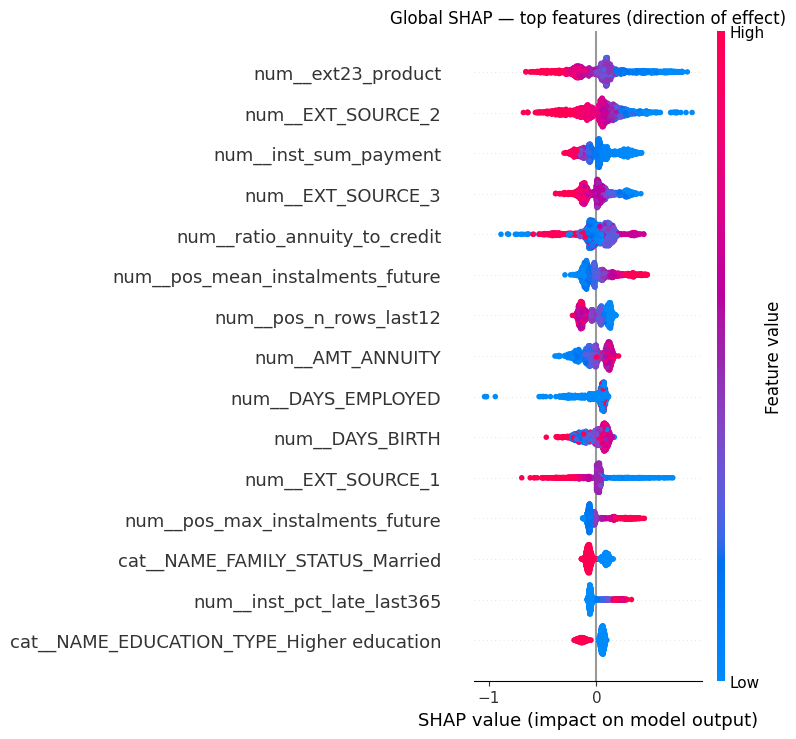

In [4]:
pre = base_pipeline.named_steps["preprocess"]
clf = base_pipeline.named_steps["clf"]
feat_names = list(pre.get_feature_names_out())

rng = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(len(X_train), size=min(200, len(X_train)), replace=False)
ex_idx = rng.choice(len(X_test), size=min(1500, len(X_test)), replace=False)

X_bg = pre.transform(X_train.iloc[bg_idx])
X_ex = pre.transform(X_test.iloc[ex_idx])

explainer = shap.TreeExplainer(clf, data=X_bg)
shap_values = explainer(X_ex, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values.values, X_ex, feature_names=feat_names, show=False, max_display=15
)
plt.title("Global SHAP — top features (direction of effect)")
plt.tight_layout()
plt.show()

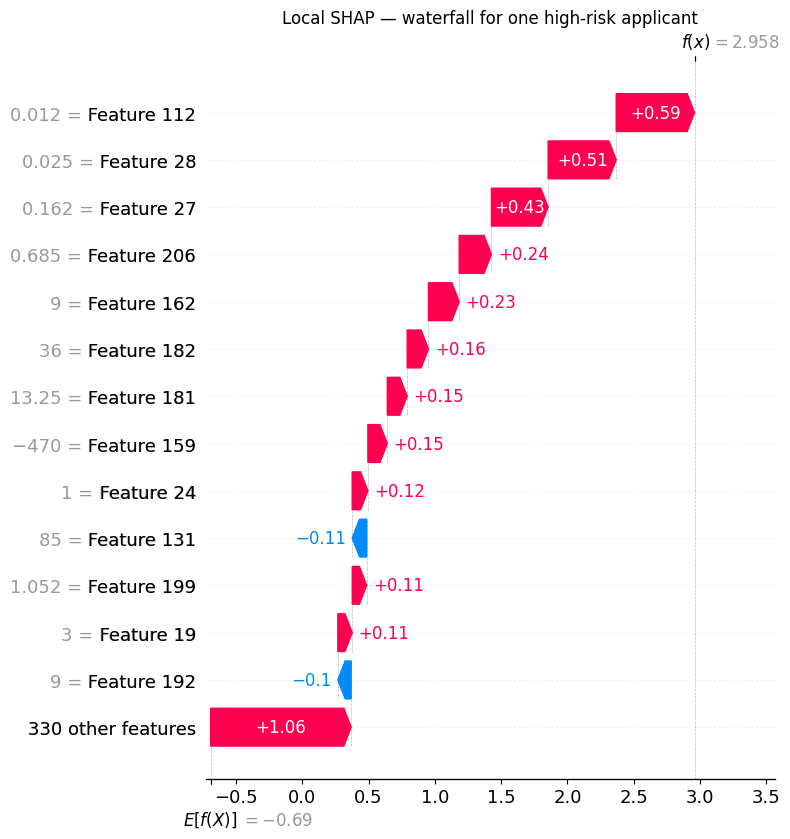

In [5]:
# Local explanation: pick a high-risk applicant in the explanation sample (calibrated p)
p_cal = cal_model.predict_proba(X_test)[:, 1]
risk_on_ex = p_cal[ex_idx]
local_row = int(np.argmax(risk_on_ex))
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[local_row], max_display=14, show=False)
plt.title("Local SHAP — waterfall for one high-risk applicant")
plt.tight_layout()
plt.show()

In [6]:
# Top-5 mean |SHAP| on the explanation sample (credit interpretation is qualitative)
mean_abs = np.abs(shap_values.values).mean(axis=0)
top5 = np.argsort(-mean_abs)[:5]
top_tbl = pd.DataFrame(
    {"feature": [feat_names[i] for i in top5], "mean_abs_shap": mean_abs[top5]}
)
display(top_tbl)
print(
    "Interpretation (example): external bureau scores and debt/income ratios typically "
    "raise predicted default risk when they move in the direction of weaker repayment capacity."
)

,feature,mean_abs_shap
0,num__ext23_product,0.202166
1,num__EXT_SOURCE_2,0.175946
2,num__inst_sum_payment,0.122752
3,num__EXT_SOURCE_3,0.113851
4,num__ratio_annuity_to_credit,0.112265


Interpretation (example): external bureau scores and debt/income ratios typically raise predicted default risk when they move in the direction of weaker repayment capacity.
